Question-1

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [146]:

np.random.seed(1234)

m = 100 
X = np.random.rand(m, 2) * 10  
true_w = np.array([3, 5])
y = X @ true_w + 10 + np.random.randn(m) * 2

In [147]:
def normalize(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

X = normalize(X)
X = np.c_[np.ones(m), X]

In [148]:
def cost(X, y, w, l1=0, l2=0):
    m = len(y)
    Z = (1/(2*m)) * np.sum((X @ w - y) ** 2)
    P = l1 * np.sum(np.abs(w))
    Q = l2 * np.sum(w ** 2)
    return Z + P + Q

In [149]:
def gradient(X, y, lr=0.01, epochs=1000, l1=0, l2=0):
    m, n = X.shape
    w = np.zeros(n)
    loss = []

    for _ in range(epochs):
        A = X @ w
        B = (1/m) * X.T @ (A- y)

    
        B += l1 * np.sign(w)
        B+= 2 * l2 * w

        w -= lr * B
        loss.append(cost(X, y, w, l1, l2))

    return w, loss

In [150]:
w_none, loss_none = gradient(X, y)
w_l1, loss_l1 = gradient(X, y, l1=0.01)
w_l2, loss_l2 = gradient(X, y, l2=0.01)

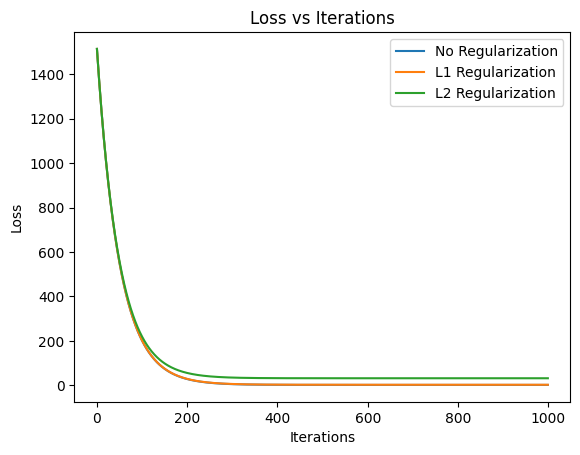

In [151]:
plt.plot(loss_none, label="No Regularization")
plt.plot(loss_l1, label="L1 Regularization")
plt.plot(loss_l2, label="L2 Regularization")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iterations")
plt.show()

6. Explain:

• Which regularization performed better and why?

L2 regularization worked better because L2 does not remove features completely it only reduces the size of weights so the model can stay balance.

• What happens to weights under L1 and L2?

What happens to weights in L1 and L2?

L1 Regularization pushes some weights to zero and it also remove less important features and it also works like feature selection

L2 Regularization makes weights small but not zero, it does not remove any features and it control overfitting very smoothly



Question-4

1 Which model would you choose and why?

 Logistic Regression model with regularization is a suitable  for this problem. It works well with large datasets and it  is fast enough for real-time predictions, and itprovides probability outputs that help in deciding whether a transaction is correct or not.

 2 Which metric is most important: Accuracy, Precision, Recall, or F1-score? Justify.

The most important metric in this condition is recall. Recall measures how many actual fraud cases are correctly identified by the model. Since false negatives are very costly and the model should focuses more  on catching  fraud cases . Accuracy is not correct in this condition because the data is imbalanced.

3.How would you handle class imbalance?
 
 Class imbalance can be handled by using  techniques like class weighting, oversampling the fraud class, and adjusting the decision threshold . 

 4.If accuracy is high but recall is low, what does it mean practically?
 
 If a model have high accuracy but low recall it means that the model is predicting most transactions as normal and missing fraud cases. Such a model is not useful in real-world fraud detection.